In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('../dataset/open-meteo_historical.csv')

In [3]:
df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2023-01-01T00:00,18.3,88,16.2,17.5,0.0,100,70,100,0,51.4,3.2,48.1,12.3,368.2
1,2023-01-01T01:00,19.0,84,16.3,18.3,0.0,99,52,99,0,79.1,0.0,79.1,0.0,610.0
2,2023-01-01T02:00,20.1,80,16.5,19.4,0.0,100,83,100,0,198.7,41.5,157.2,74.0,794.2
3,2023-01-01T03:00,20.0,81,16.7,19.5,0.0,100,74,100,0,125.0,0.0,125.0,0.0,908.4
4,2023-01-01T04:00,19.7,83,16.7,19.3,0.1,100,96,100,0,117.4,3.0,114.4,4.5,944.8


In [4]:
df.set_index('time', inplace=True)

df.head()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
time,,,,,,,,,,,,,,
2023-01-01T00:00,18.3,88,16.2,17.5,0.0,100,70,100,0,51.4,3.2,48.1,12.3,368.2
2023-01-01T01:00,19.0,84,16.3,18.3,0.0,99,52,99,0,79.1,0.0,79.1,0.0,610.0
2023-01-01T02:00,20.1,80,16.5,19.4,0.0,100,83,100,0,198.7,41.5,157.2,74.0,794.2
2023-01-01T03:00,20.0,81,16.7,19.5,0.0,100,74,100,0,125.0,0.0,125.0,0.0,908.4
2023-01-01T04:00,19.7,83,16.7,19.3,0.1,100,96,100,0,117.4,3.0,114.4,4.5,944.8


In [5]:
print(df.shape)

(8760, 14)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 2023-01-01T00:00 to 2023-12-31T23:00
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   temperature_2m (°C)                      8760 non-null   float64
 1   relative_humidity_2m (%)                 8760 non-null   int64  
 2   dew_point_2m (°C)                        8760 non-null   float64
 3   apparent_temperature (°C)                8760 non-null   float64
 4   rain (mm)                                8760 non-null   float64
 5   cloud_cover (%)                          8760 non-null   int64  
 6   cloud_cover_low (%)                      8760 non-null   int64  
 7   cloud_cover_mid (%)                      8760 non-null   int64  
 8   cloud_cover_high (%)                     8760 non-null   int64  
 9   shortwave_radiation_instant (W/m²)       8760 non-null   float64
 10  direct_radiation_instant (

In [7]:
data_features = df[['temperature_2m (°C)', 'relative_humidity_2m (%)', 'dew_point_2m (°C)',
                    'apparent_temperature (°C)', 'rain (mm)', 'cloud_cover (%)', 'cloud_cover_low (%)',
                    'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'shortwave_radiation_instant (W/m²)', 
                    'diffuse_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
                    'direct_normal_irradiance_instant (W/m²)', 'terrestrial_radiation_instant (W/m²)']].values
data_target = df['diffuse_radiation_instant (W/m²)'].values

In [8]:
print(len(data_features))

8760


In [9]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 1 # predict 1 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    print("i: ", i)
    print("untuk x seq: ", i + look_back)
    print("i + lookback: ", i + look_back)
    print("i + look_back + n_ahead: ", i + look_back + n_ahead)
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 1 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

i:  0
untuk x seq:  24
i + lookback:  24
i + look_back + n_ahead:  25
i:  1
untuk x seq:  25
i + lookback:  25
i + look_back + n_ahead:  26
i:  2
untuk x seq:  26
i + lookback:  26
i + look_back + n_ahead:  27
i:  3
untuk x seq:  27
i + lookback:  27
i + look_back + n_ahead:  28
i:  4
untuk x seq:  28
i + lookback:  28
i + look_back + n_ahead:  29
i:  5
untuk x seq:  29
i + lookback:  29
i + look_back + n_ahead:  30
i:  6
untuk x seq:  30
i + lookback:  30
i + look_back + n_ahead:  31
i:  7
untuk x seq:  31
i + lookback:  31
i + look_back + n_ahead:  32
i:  8
untuk x seq:  32
i + lookback:  32
i + look_back + n_ahead:  33
i:  9
untuk x seq:  33
i + lookback:  33
i + look_back + n_ahead:  34
i:  10
untuk x seq:  34
i + lookback:  34
i + look_back + n_ahead:  35
i:  11
untuk x seq:  35
i + lookback:  35
i + look_back + n_ahead:  36
i:  12
untuk x seq:  36
i + lookback:  36
i + look_back + n_ahead:  37
i:  13
untuk x seq:  37
i + lookback:  37
i + look_back + n_ahead:  38
i:  14
untuk x s

In [10]:
print(x_seq.shape)
print(y_seq.shape)

(8736, 24, 14)
(8736, 1)


In [11]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (6988, 24, 14), x_test shape: (1748, 24, 14)
y_train shape: (6988,), y_test shape: (1748,)


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, 14)).reshape(x_train.shape[0], x_train.shape[1], 14) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, 14)).reshape(x_test.shape[0], x_test.shape[1], 14)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (6988, 24, 14), X_test_scaled shape: (1748, 24, 14)
y_train_scaled shape: (6988, 1), y_test_scaled shape: (1748, 1)


In [13]:
import tensorflow as tf

In [14]:
#define the sequential LSTM model with tf.keras.Input layer

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(look_back, 14))) #explicit input layer using tf.keras.input (timesteps, features)

#add LSTM layers with dropout and regularization
model.add(tf.keras.layers.LSTM(128)) #LSTM layer with 50 units and L2
model.add(tf.keras.layers.Dropout(0.2)) #dropout layer with 20%

# Output layer for 1 target step
model.add(tf.keras.layers.Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Model summary to show architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,345 (286.50 KB)

 Trainable params: 73,345 (286.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the model
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(x_train_scaled, y_train_scaled, epochs=100, batch_size=150, validation_split=0.2, shuffle=False, callbacks=[early_stopping])


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2705 - val_loss: 0.1009
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3529 - val_loss: 0.0680
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0973 - val_loss: 0.0489
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0695 - val_loss: 0.0463
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0653 - val_loss: 0.0433
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0587 - val_loss: 0.0426
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0541 - val_loss: 0.0415
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0555 - val_loss: 0.0411
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0572 - val_loss: 0.0414
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0549 - val_loss: 0.0418
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0535 - val_loss: 0.0400
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

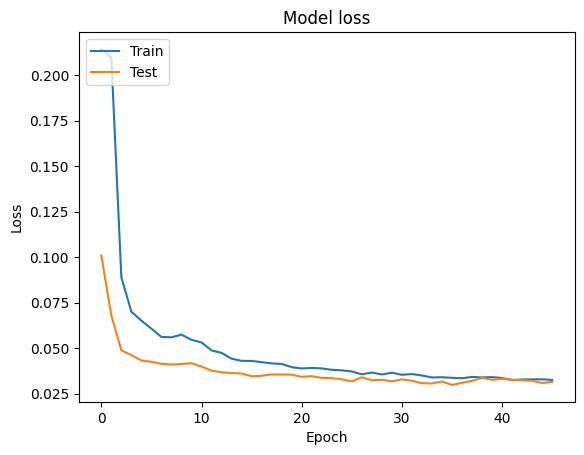

In [16]:
# prompt: plot the loss history of training and validation

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [17]:
#Evaluate the model

test_loss = model.evaluate(x_test_scaled, y_test_scaled)
print(f"Test Loss: {test_loss}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1525
Test Loss: 0.130294069647789


In [18]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled).flatten()


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 36.2592830700706
Mean Squared Error (MSE): 2690.532557593239


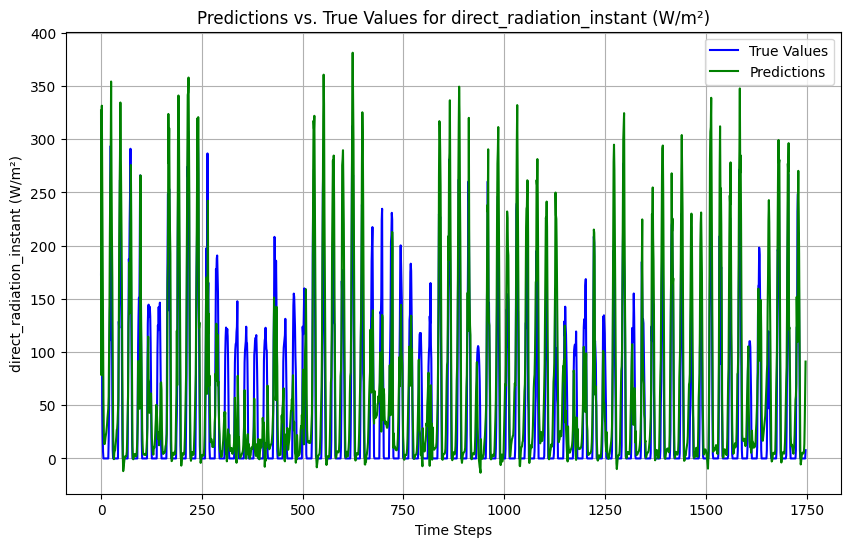

In [20]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for direct_radiation_instant (W/m²)')
plt.xlabel('Time Steps')
plt.ylabel('direct_radiation_instant (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

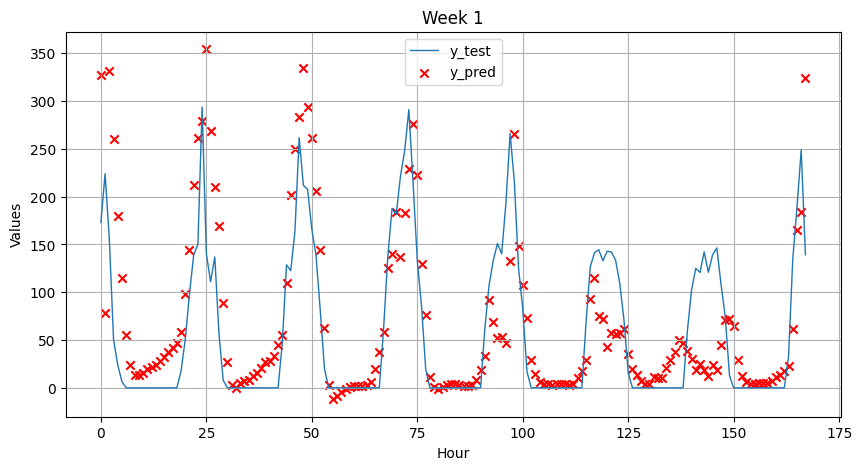

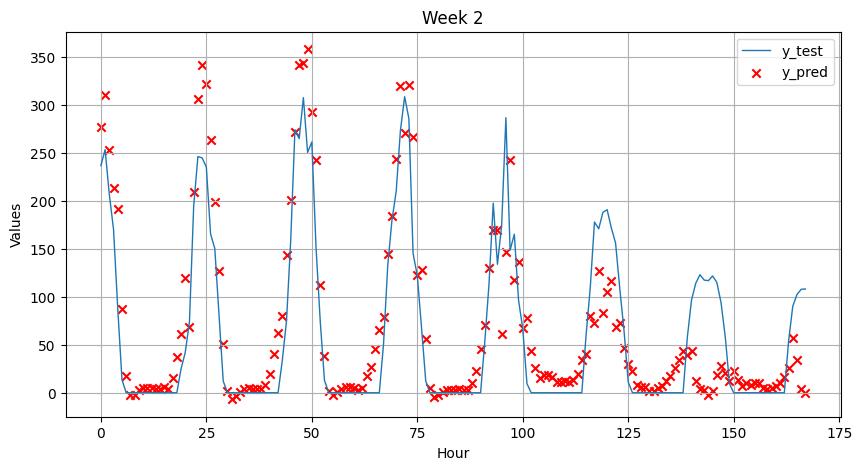

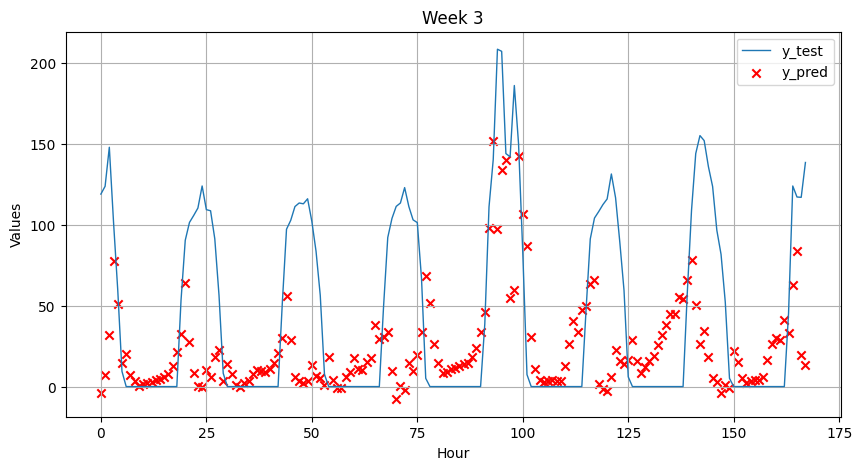

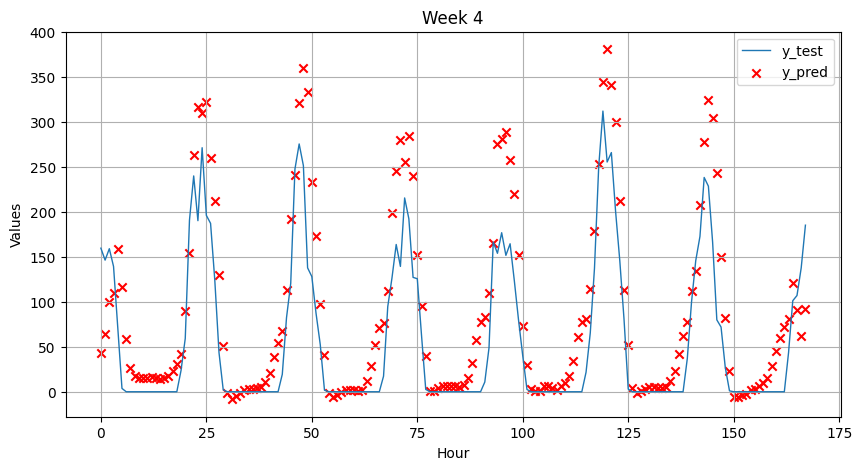

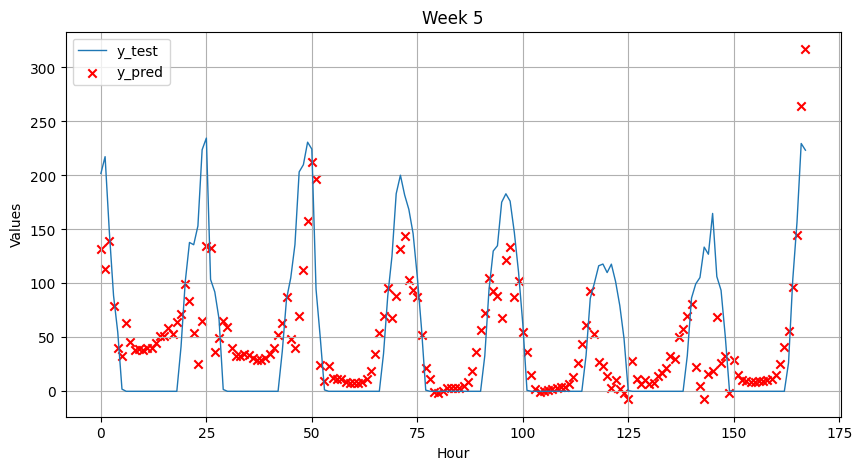

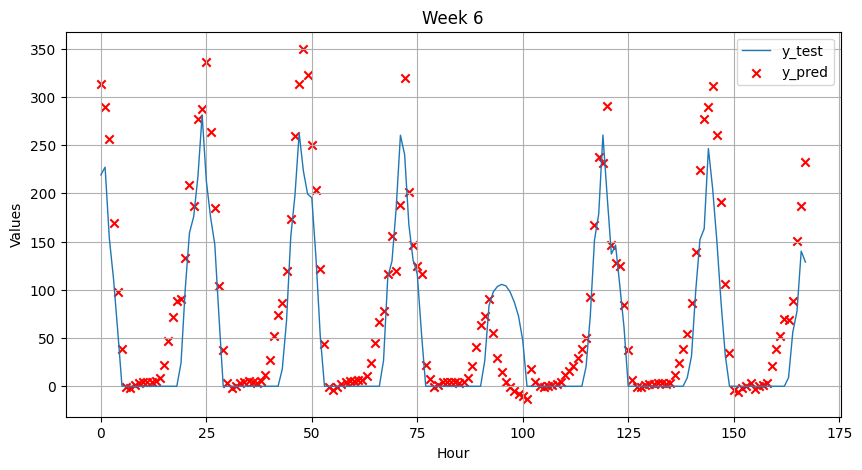

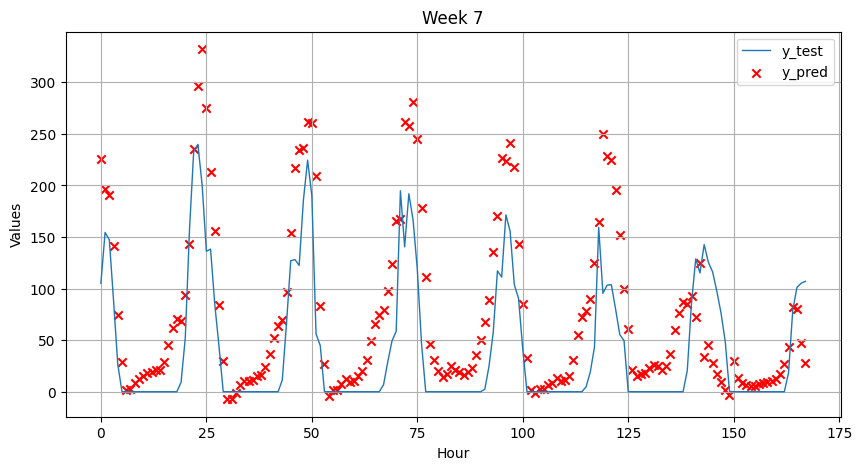

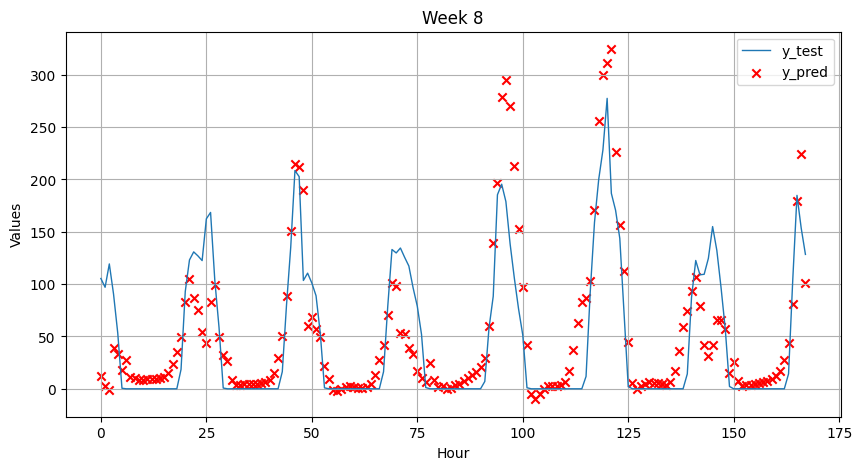

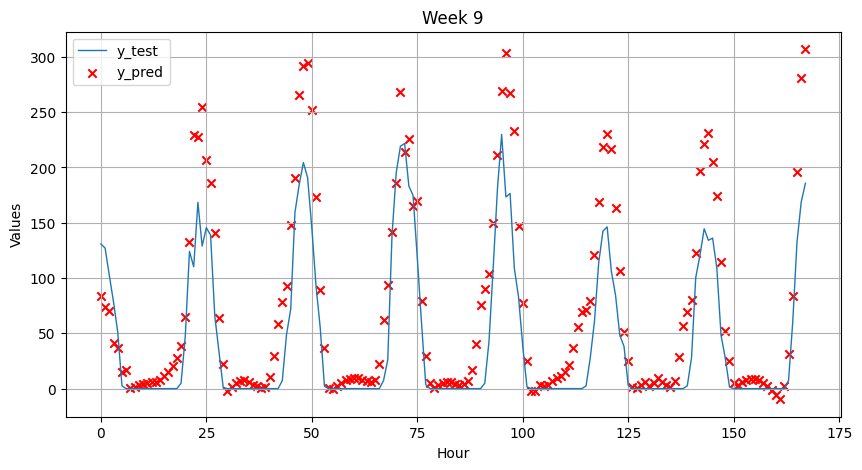

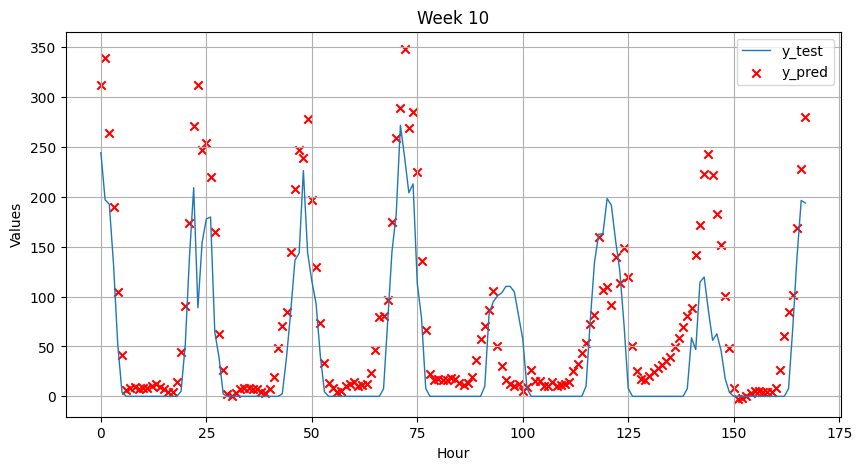

In [21]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()